In [93]:
%matplotlib inline
import torch
from matplotlib_inline.backend_inline import set_matplotlib_formats
from matplotlib import pyplot as plt
import numpy as np
import random

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

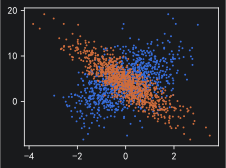

In [116]:
def use_svg_display():
    # 用矢量图显示
    set_matplotlib_formats('svg')

def set_figsize(figsize = (3.5, 2.5)):
    use_svg_display()
    #设置图的尺寸
    plt.rcParams['figure.figsize'] = figsize

set_figsize()
plt.scatter(features[:, 0].numpy(), labels.numpy(), 1)
plt.scatter(features[:, 1].numpy(), labels.numpy(), 1)

In [95]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        j = torch.LongTensor(indices[i: min(i + batch_size, num_examples)])
        yield features.index_select(0, j), labels.index_select(0, j)

In [96]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X)
    print(y)
    break

tensor([[-0.5592, -0.1182],
        [-1.9455, -1.7800],
        [-1.5075,  0.5820],
        [ 0.6782, -1.4308],
        [-1.0873, -1.3859],
        [-0.6889,  1.3934],
        [-1.8798,  0.2833],
        [-0.5740, -0.4447],
        [ 0.3667,  0.8201],
        [-1.2547, -2.1990]])
tensor([ 3.4988,  6.3623, -0.8036, 10.4205,  6.7360, -1.8991, -0.5170,  4.5758,
         2.1370,  9.1688])


In [97]:
# 初始化参数
w = torch.tensor(np.random.normal(0, 0.01, (num_inputs, 1)), dtype=torch.float32)
b = torch.zeros(1, dtype=torch.float32)

w.requires_grad_(True)
b.requires_grad_(True)

tensor([0.], requires_grad=True)

In [98]:
def linreg(X, w, b):
    return torch.mm(X, w) + b

def squared_loss(y_hat, y):
    return (y_hat - y.view(y_hat.size())) ** 2 / 2

def sgd(params, lr, batch_size):
    for param in params:
        param.data -= lr * param.grad / batch_size

In [99]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y).sum()
        l.backward()
        sgd([w ,b], lr, batch_size)

        w.grad.data.zero_()
        b.grad.data.zero_()

    train_l = loss(net(features, w, b), labels)
    print('epoch %d, loss %f' % (epoch + 1, train_l.mean().item()))

epoch 1, loss 0.034370
epoch 2, loss 0.000126
epoch 3, loss 0.000050


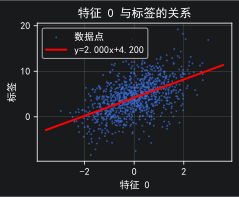

特征 0: w=1.9998, b=4.1997
数据范围: [-2.96, 2.99]


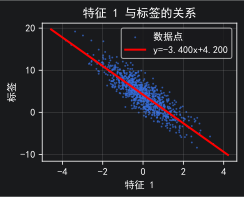

特征 1: w=-3.3998, b=4.1997
数据范围: [-3.83, 3.48]


In [117]:
def showImg(index):
    """显示第 index 个特征与标签的关系及拟合线"""
    # 1. 提取数据和参数
    x_data = features[:, index].cpu().numpy()
    y_data = labels.cpu().numpy()
    w_val = w.data[index].cpu().item()
    b_val = b.data[0].cpu().item()

    # 2. 根据数据范围生成拟合线（更合理）
    x_min, x_max = x_data.min(), x_data.max()
    x_padding = (x_max - x_min) * 0.1  # 留10%边距
    x_l = np.linspace(x_min - x_padding, x_max + x_padding, 100)
    y_l = w_val * x_l + b_val

    # 3. 绘图
    set_figsize()
    plt.scatter(x_data, y_data, s=1, alpha=0.6, label='数据点')
    plt.plot(x_l, y_l, 'r-', linewidth=2, label=f'y={w_val:.3f}x+{b_val:.3f}')

    plt.xlabel(f'特征 {index}')
    plt.ylabel('标签')
    plt.title(f'特征 {index} 与标签的关系')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 4. 打印信息
    print(f"特征 {index}: w={w_val:.4f}, b={b_val:.4f}")
    print(f"数据范围: [{x_min:.2f}, {x_max:.2f}]")

showImg(0)
showImg(1)